In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
housing = pd.read_csv(url)


In [17]:
housing.head(10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [18]:
housing.dtypes


,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity,object


In [19]:
housing.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


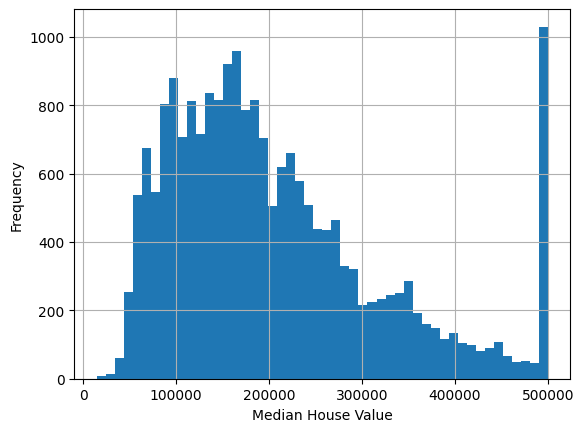

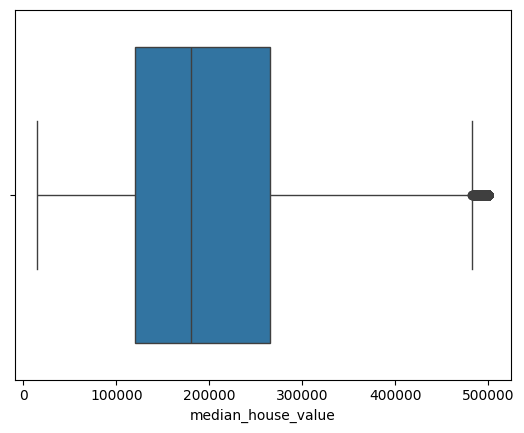

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
plt.figure()
housing['median_house_value'].hist(bins=50)
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

# Box Plot
plt.figure()
sns.boxplot(x=housing['median_house_value'])
plt.show()


In [21]:
missing_percentage = housing.isnull().mean() * 100
missing_percentage


,0
longitude,0.000000
latitude,0.000000
housing_median_age,0.000000
total_rooms,0.000000
total_bedrooms,1.002907
population,0.000000
households,0.000000
median_income,0.000000
median_house_value,0.000000
ocean_proximity,0.000000


In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing['total_bedrooms'] = imputer.fit_transform(
    housing[['total_bedrooms']]
)


In [24]:
housing_encoded = pd.get_dummies(
    housing,
    columns=['ocean_proximity'],
    drop_first=True
)


In [25]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler(feature_range=(0, 1))

numeric_features = housing_encoded.select_dtypes(include=['float64', 'int64']).columns

housing_encoded[numeric_features] = minmax_scaler.fit_transform(
    housing_encoded[numeric_features]
)


In [27]:
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

# Create 'income_cat' on the original housing DataFrame first
housing['income_cat'] = pd.cut(
    housing['median_income'],
    bins=[0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5]
)

# Add 'income_cat' to the housing_encoded DataFrame
housing_encoded['income_cat'] = housing['income_cat']

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in split.split(housing_encoded, housing_encoded['income_cat']):
    strat_train = housing_encoded.loc[train_idx]
    strat_test = housing_encoded.loc[test_idx]

strat_train.drop('income_cat', axis=1, inplace=True)
strat_test.drop('income_cat', axis=1, inplace=True)

In [28]:
corr_matrix = strat_train.corr()


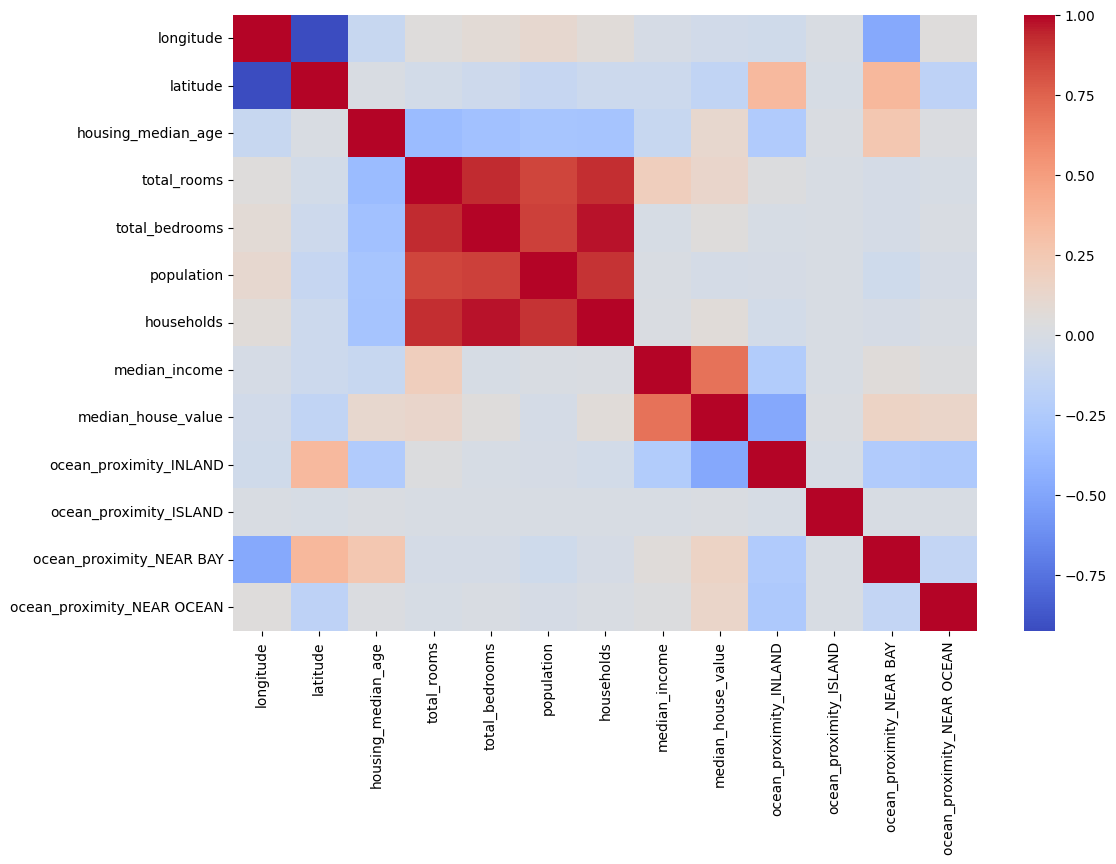

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.show()


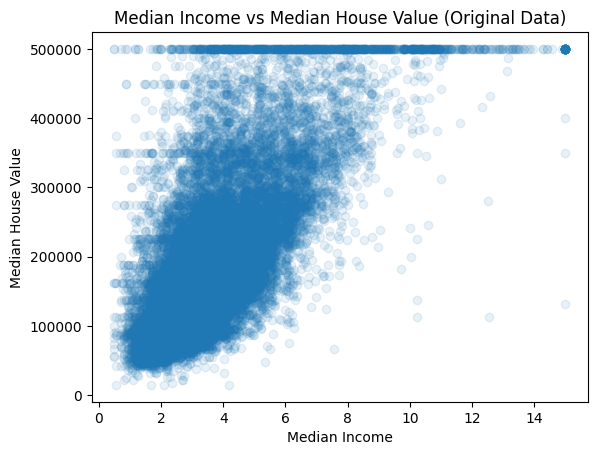

In [37]:
plt.figure()
plt.scatter(
    housing['median_income'],
    housing['median_house_value'],
    alpha=0.1
)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value (Original Data)")
plt.show()

In [31]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    housing_encoded,
    test_size=0.2,
    random_state=42
)


In [32]:
corr_target = corr_matrix['median_house_value'].sort_values(ascending=False)
corr_target


,median_house_value
median_house_value,1.000000
median_income,0.687151
ocean_proximity_NEAR BAY,0.158691
ocean_proximity_NEAR OCEAN,0.137332
total_rooms,0.135140
housing_median_age,0.114146
households,0.064590
total_bedrooms,0.047732
ocean_proximity_ISLAND,0.013708
population,-0.026882


In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_set[numeric_features] = scaler.fit_transform(train_set[numeric_features])
test_set[numeric_features] = scaler.transform(test_set[numeric_features])


In [34]:
from sklearn.linear_model import LinearRegression

X_train = train_set.drop('median_house_value', axis=1)
y_train = train_set['median_house_value']

X_test = test_set.drop('median_house_value', axis=1)
y_test = test_set['median_house_value']

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)


LinearRegression()

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = lin_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

rmse, mae, r2


(np.float64(0.605787984146388), 0.43986704551058153, 0.6256362335780752)